# AI Destekli Müşteri Analitiği Projesi
## Customer Segmentation + Churn Prediction + Behavioral Analysis

Bu notebook tek bir uçtan uca akıştır: veri ön işleme → öznitelik mühendisliği →
müşteri segmentasyonu → churn tahmini → davranışsal kural çıkarımı → müşteri değeri →
özet dashboard → model açıklanabilirliği (SHAP) → bonus birliktelik analizi (Apriori).

**Akış**
1. Problem tanımı
2. Veri yükleme ve ön işleme
3. Öznitelik mühendisliği (RFM)
4. Müşteri segmentasyonu (K-Means)
5. Churn tahmini (Logistic Regression + Random Forest)
6. Davranışsal kural çıkarımı
7. Müşteri değeri analizi
8. Özet dashboard
9. Model açıklanabilirliği (Feature importance + SHAP + Confusion Matrix)
10. Bonus: Sentetik veri ile Apriori birliktelik analizi
11. Sonuç ve öneriler


> **Bu, projenin açıklamalı (anlatımlı) sürümüdür.** Her kod hücresinin hemen üstünde, o
> hücrenin *ne yaptığını*, *arkasındaki mantığı*, *neden o tercihin yapıldığını* ve
> *sonucun nasıl yorumlanacağını* anlatan bir açıklama bulunur. Kod, ana proje notebook'u
> (`CRM_Project.ipynb`) ile birebir aynıdır; burada eklenen tek şey açıklama metinleridir.

## 1. Problem Tanımı

Müşteri kaybını (churn) azaltmak, yüksek değerli müşterileri belirlemek ve kullanıcı
davranışlarını anlamak amacıyla veri analizi ve makine öğrenmesi teknikleri kullanılmıştır.
Çalışma üç soruya yanıt arar: *(i)* Müşteriler hangi davranışsal gruplara ayrılır?
*(ii)* Hangi müşteriler ayrılma riski taşır? *(iii)* Hangi davranış örüntüleri churn ve
sadakatle ilişkilidir?

## Kurulum ve Kütüphaneler

### Açıklama — Kütüphaneler ve sabitler

**Ne yapar:** Tüm projede kullanılacak kütüphaneleri tek yerde içe aktarır ve global
ayarları (grafik teması, sabit `RANDOM_STATE`, churn renk paleti) tanımlar.

**Mantık:** `sklearn`'den ön işleme (`StandardScaler`), kümeleme (`KMeans`), model
(`LogisticRegression`, `RandomForestClassifier`) ve metrik fonksiyonları ayrı ayrı çağrılır.

**Neden böyle:** `RANDOM_STATE = 42` her çalıştırmada **aynı sonucu** almak içindir —
train/test bölünmesi, K-Means başlangıçları ve RF hepsi bu tohuma bağlanır, böylece
sonuçlar tekrarlanabilir olur (sunum/rapor için kritik). Renk paletini sabitlemek de tüm
grafiklerde "kalan = yeşil, ayrılan = kırmızı" tutarlılığını sağlar.

In [1]:
# Colab'da SHAP ve mlxtend kurulu değilse:
# !pip install shap mlxtend -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, recall_score,
                             precision_score, f1_score, accuracy_score)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
CHURN_PAL = {0: "#4C9F70", 1: "#D1495B"}
print("Hazır.")

Hazır.


## 2. Veri Yükleme ve Ön İşleme

Adımlar: PII kolonlarını çıkar → mantıken imkânsız değerleri (negatif satın alma, %100'ü
aşan oranlar, aşırı yaş) düzelt → eksik değerleri doldur → çok boş kolonları (eşik %40) sil.

### Açıklama — Veriyi yükleme ve PII çıkarma

**Ne yapar:** CSV'yi okur ve `name`, `email`, `phone` kolonlarını siler.

**Mantık:** Bu üç kolon kişiyi tanımlayan bilgidir (PII) ve modele bir şey katmaz.

**Neden böyle:** İsim/e-posta/telefon ne segmentasyona ne churn tahminine sinyal taşır;
üstelik modele sokmak hem gürültü ekler hem gizlilik açısından sakıncalıdır. `TARGET`,
`ID_COLS`, `CATEGORICAL` değişkenlerini baştan tanımlamak, ilerideki adımlarda kolon
gruplarına tek isimden erişmeyi sağlar.

In [2]:
DATA_PATH = "customers.csv"   # Colab'da dosyayı notebook ile aynı dizine koy
df = pd.read_csv(DATA_PATH)
print("Ham veri:", df.shape)

TARGET = "Churned"
ID_COLS = ["name", "email", "phone"]
CATEGORICAL = ["Gender", "Country", "City", "Signup_Quarter"]

# 2.1 PII kolonlarını çıkar
df = df.drop(columns=ID_COLS)
print("PII çıkarıldı ->", df.shape)

Ham veri: (50000, 28)
PII çıkarıldı -> (50000, 25)


### Açıklama — Veri kalitesi düzeltmeleri

**Ne yapar:** Mantıken imkânsız değerleri düzeltir: 13 yaş altı / 100 üstü yaşları ve
negatif satın alma sayılarını `NaN` yapar; yüzde olması gereken kolonları `[0, 100]`
aralığına kırpar (clip).

**Mantık:** EDA'da `Age` max=200, `Total_Purchases` min=−13, `Cart_Abandonment_Rate`
%143 gibi değerler bulduk — bunlar veri giriş hatasıdır.

**Neden böyle:** Hatalı değeri silmek yerine `NaN`'a çeviriyoruz ki bir sonraki adımdaki
**doldurma** (imputation) mantığı bunları makul bir değerle (medyan) doldursun. Oranları
silmek yerine kırpıyoruz çünkü "%143 terk" aslında "%100 terk" demek istemiş olabilir;
bilgi tümden atılmasın diye sınıra çekiyoruz. Bu adım modelin **çöp veriden** öğrenmesini
engeller (garbage in, garbage out).

In [3]:
# 2.2 Veri kalitesi düzeltmeleri (hatalı değerleri NaN/sınıra çek)
before_na = df.isna().sum().sum()

# Yaş makul aralık dışı -> NaN
df.loc[(df["Age"] < 13) | (df["Age"] > 100), "Age"] = np.nan
# Negatif satın alma imkansız -> NaN
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = np.nan
# Yüzde kolonlarını [0, 100] aralığına kırp
rate_cols = ["Cart_Abandonment_Rate", "Returns_Rate",
             "Discount_Usage_Rate", "Email_Open_Rate"]
for c in rate_cols:
    df[c] = df[c].clip(lower=0, upper=100)

print(f"Düzeltme sonrası eklenen NaN: {df.isna().sum().sum() - before_na}")

Düzeltme sonrası eklenen NaN: 90


### Açıklama — Boş kolon eleme + eksik değer doldurma

**Ne yapar:** Önce %40'tan fazla boş olan kolonları siler (bu veride yok). Sonra kalan
eksikleri doldurur: sayısal kolonlar **medyan**, kategorik kolonlar **mod** (en sık değer).

**Mantık:** Eksik veri ile çoğu model çalışmaz; ya satırı sil ya değeri doldur. 50.000
satırın %5–12'sini silmek çok veri kaybı olurdu, o yüzden dolduruyoruz.

**Neden medyan (ortalama değil):** Medyan **aykırı değerlere dayanıklıdır**. `Average_Order_Value`
gibi sağa çarpık, birkaç çok büyük değer içeren kolonlarda ortalama yukarı kayar; medyan
tipik müşteriyi daha iyi temsil eder. Kategoriklerde mod, en olası sınıfı koyar.

In [4]:
# 2.3 Çok boş kolonları sil (eşik %40) — bu veride hiçbiri eşiği aşmıyor
THRESH = 0.40
high_missing = df.columns[df.isna().mean() > THRESH].tolist()
print("Silinecek kolon (>%40 boş):", high_missing if high_missing else "yok")
df = df.drop(columns=high_missing)

# 2.4 Eksik değer doldurma: sayısal -> median, kategorik -> mode
num_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET)
cat_cols = [c for c in CATEGORICAL if c in df.columns]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Kalan eksik değer:", df.isna().sum().sum())

Silinecek kolon (>%40 boş): yok
Kalan eksik değer: 0


## 3. Öznitelik Mühendisliği — RFM

RFM, müşteriyi üç eksende skorlar: **Recency** (son alışveriştan bu yana geçen gün — düşük
iyi), **Frequency** (etkileşim/işlem sıklığı), **Monetary** (yaşam boyu değer). Her ekseni
4 dilime böler ve 3–12 arası bir toplam skor üretir.

### Açıklama — RFM öznitelik mühendisliği

**Ne yapar:** Üç yeni skor üretir — **R** (Recency: son alışverişten bu yana gün),
**F** (Frequency: login sıklığı), **M** (Monetary: yaşam boyu değer) — her birini 4 dilime
(`qcut`) böler ve toplayıp 3–12 arası `RFM_Score` oluşturur.

**Mantık:** RFM, pazarlamada müşteri değerini özetleyen klasik bir çerçevedir. `qcut` veriyi
**çeyreklere** (eşit sayıda müşteri içeren 4 gruba) ayırır.

**Neden böyle / dikkat:** Recency'de **düşük gün = iyi** olduğu için etiketleri ters
sıraladık (`[4,3,2,1]`): yani yakın zamanda alışveriş yapan müşteri 4 puan alır.
`rank(method="first")` ile beraberlik (aynı değerli müşteriler) durumunda `qcut`'ın hata
vermesini engelliyoruz.

**Sonucu nasıl okunur:** Sağdaki grafikte RFM skoru yükseldikçe churn oranının düşmesini
bekleriz — yani değerli/aktif müşteri daha az ayrılır. Bu, RFM'in churn ile ilişkili
olduğunun ilk kanıtıdır.

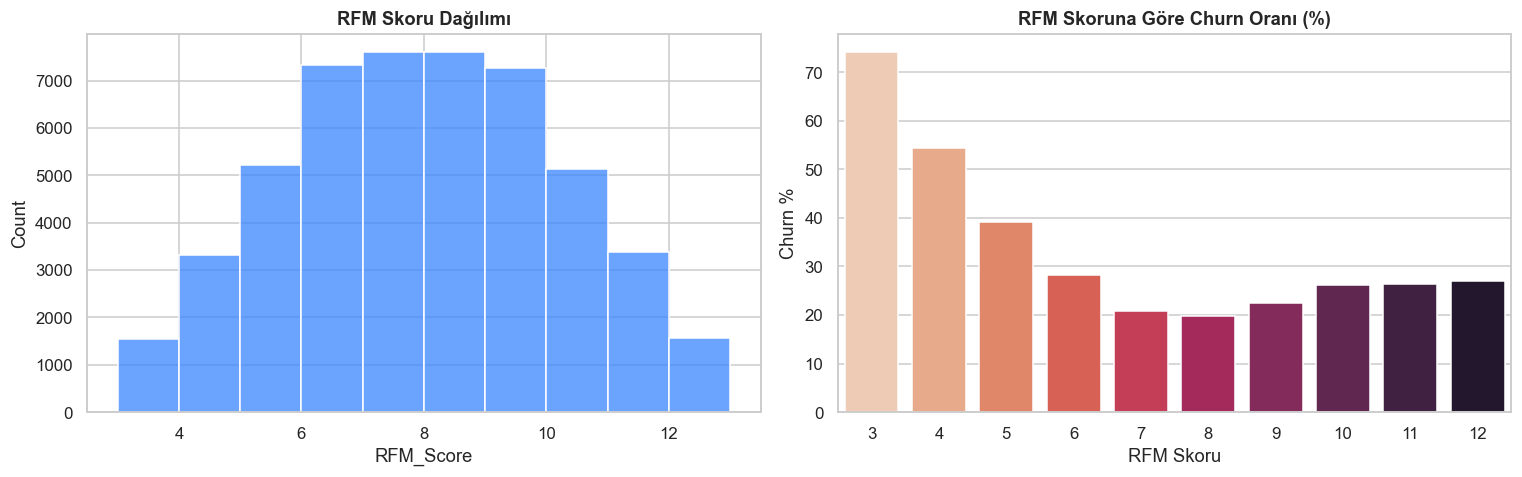

In [5]:
df["R_Score"] = pd.qcut(df["Days_Since_Last_Purchase"].rank(method="first"),
                        4, labels=[4, 3, 2, 1]).astype(int)   # düşük recency = iyi
df["F_Score"] = pd.qcut(df["Login_Frequency"].rank(method="first"),
                        4, labels=[1, 2, 3, 4]).astype(int)
df["M_Score"] = pd.qcut(df["Lifetime_Value"].rank(method="first"),
                        4, labels=[1, 2, 3, 4]).astype(int)
df["RFM_Score"] = df[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["RFM_Score"], bins=range(3, 14), color="#3A86FF", ax=ax[0])
ax[0].set_title("RFM Skoru Dağılımı")
churn_by_rfm = df.groupby("RFM_Score")[TARGET].mean() * 100
sns.barplot(x=churn_by_rfm.index, y=churn_by_rfm.values, palette="rocket_r", ax=ax[1])
ax[1].set_title("RFM Skoruna Göre Churn Oranı (%)")
ax[1].set_xlabel("RFM Skoru"); ax[1].set_ylabel("Churn %")
plt.tight_layout(); plt.show()

## 4. Müşteri Segmentasyonu (K-Means)

Davranışsal eksenlerde (LTV, toplam satın alma, login sıklığı, indirim kullanımı) müşterileri
gruplarız. Önce uygun k'yı elbow ve silhouette ile seçer, sonra segmentleri profilleriz.

### Açıklama — Segmentasyon için k seçimi (Elbow + Silhouette)

**Ne yapar:** Segmentasyon özniteliklerini (`Lifetime_Value`, `Total_Purchases`,
`Login_Frequency`, `Discount_Usage_Rate`) **standartlaştırır** ve k=2..6 için iki ölçüt
hesaplar: Elbow (inertia) ve Silhouette.

**Mantık:** K-Means'te kaç küme (k) seçileceğini veri söyler. Inertia = noktaların kendi
küme merkezine uzaklıklarının karesi; k arttıkça düşer. Silhouette = kümelerin ne kadar
ayrık olduğu (−1 ile 1 arası; yüksek iyi).

**Neden standartlaştırma şart:** K-Means **uzaklık** temellidir. `Lifetime_Value` (binlerce)
ile `Login_Frequency` (onlarca) aynı ölçekte değilse, büyük sayılı kolon mesafeye hâkim olur.
`StandardScaler` hepsini ortalama 0 / std 1'e çeker, böylece her öznitelik eşit söz sahibi olur.

**Sonucu nasıl okunur:** Elbow grafiğinde eğrinin "dirsek" yaptığı (düşüşün yavaşladığı)
nokta ve Silhouette'in tepe yaptığı k iyi adaydır.

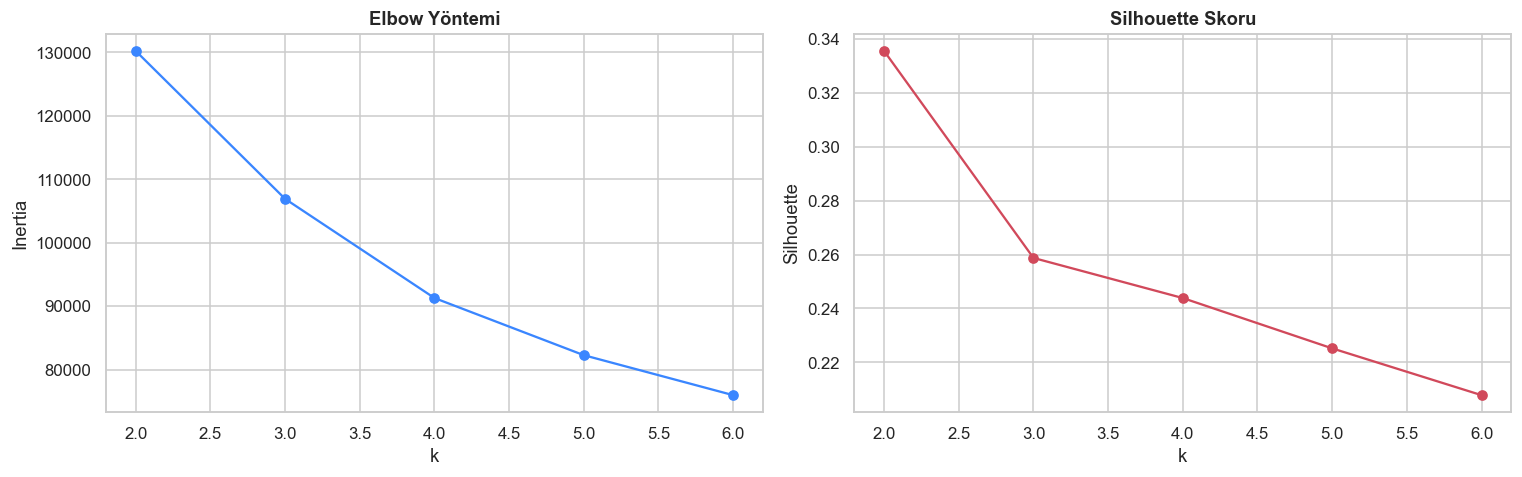

In [6]:
seg_features = ["Lifetime_Value", "Total_Purchases",
                "Login_Frequency", "Discount_Usage_Rate"]
X_seg = StandardScaler().fit_transform(df[seg_features])

inertias, sils = [], []
K_RANGE = range(2, 7)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_seg)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_seg, km.labels_, sample_size=5000,
                                 random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(list(K_RANGE), inertias, "o-", color="#3A86FF")
ax[0].set_title("Elbow Yöntemi"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_RANGE), sils, "o-", color="#D1495B")
ax[1].set_title("Silhouette Skoru"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

### Açıklama — K-Means modeli ve segment profili

**Ne yapar:** k=4 ile K-Means'i çalıştırır, her müşteriye bir `Segment` atar, sonra her
segmentin ortalama profilini (öznitelik ortalamaları + churn oranı + müşteri sayısı) tablolar.

**Mantık:** Kümeleme **gözetimsizdir** — etiket kullanmaz, sadece davranış benzerliğine göre
gruplar. Profil tablosu, her kümenin "kim olduğunu" anlamamızı sağlar.

**Neden k=4:** Yol haritasındaki dört iş segmenti (High Value / Discount Lovers / Passive /
At Risk) ile uyumlu; bir önceki hücredeki ölçütler de bu civarı destekliyorsa makul seçim.

**Sonucu nasıl okunur:** Profil tablosunda bir kümenin `Lifetime_Value` ve `Total_Purchases`
yüksekse → değerli müşteri; `Discount_Usage_Rate` yüksekse → indirim avcısı; `Login_Frequency`
düşük + churn yüksekse → riskli/pasif. Bu yorumlar bir sonraki hücrede otomatikleştirilir.

In [7]:
# Seçilen k ile son model
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["Segment"] = kmeans.fit_predict(X_seg)

# Segment profili
profile = df.groupby("Segment")[seg_features].mean().round(1)
profile["Churn_Rate_%"] = (df.groupby("Segment")[TARGET].mean() * 100).round(1)
profile["Müşteri_Sayısı"] = df["Segment"].value_counts().sort_index()
profile

,Lifetime_Value,Total_Purchases,Login_Frequency,Discount_Usage_Rate,Churn_Rate_%,Müşteri_Sayısı
Segment,,,,,,
0,2877.4,23.3,21.8,45.5,26.2,7478
1,1195.7,11.6,9.6,67.3,23.5,11665
2,801.8,7.8,5.3,32.3,38.6,16252
3,1611.5,15.0,15.1,30.2,23.9,14605


### Açıklama — Segmentlere iş anlamı kazandırma (otomatik isimlendirme)

**Ne yapar:** Segment profilini **z-skora** çevirir (her özniteliğin segment-ortalamasının,
genel ortalamadan kaç standart sapma uzakta olduğu) ve basit kurallarla iş ismi atar.

**Mantık:** K-Means kümelere yalnızca 0,1,2,3 gibi numara verir; bunların hangisinin "High
Value" olduğu çalıştırmaya göre değişir. z-skor karşılaştırması ile ismi **profile göre**
veririz, numaraya göre değil.

**Neden z-skor:** Farklı ölçekli öznitelikleri kıyaslamak için ortak bir birime ("ortalamadan
kaç sapma") çeviririz. `ltv > 0.5` → bu segment LTV'de belirgin biçimde ortalama üstü demektir.

**Sonucu nasıl okunur:** Çıktıdaki "Segment X → isim" eşlemesi ve segment dağılım grafiği,
müşteri tabanının iş diliyle kaç gruba ayrıldığını gösterir. (Kurallar basit olduğundan
isimler illüstratiftir; profil tablosuyla birlikte yorumlanmalı.)

Segment isimleri (profile göre):
  Segment 0 -> High Value
  Segment 1 -> Discount Lovers
  Segment 2 -> Passive / At Risk
  Segment 3 -> Standart


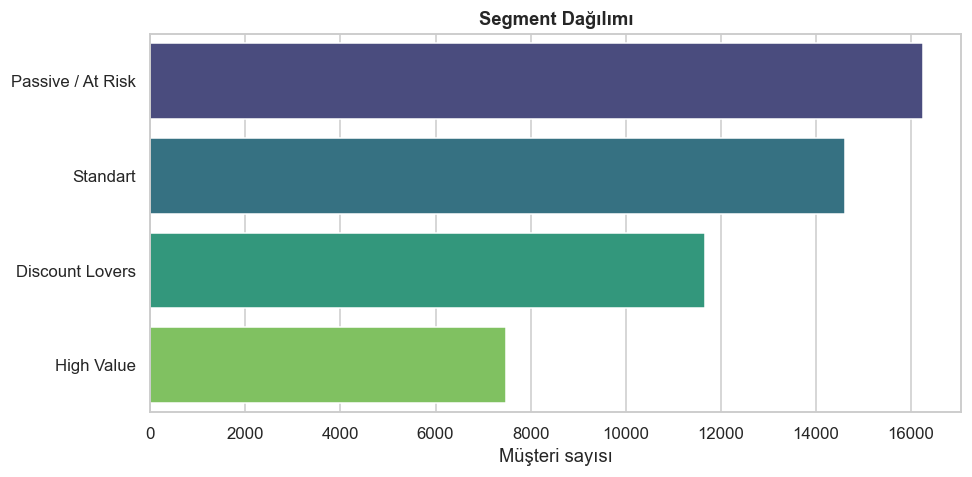

In [8]:
# Profillere göre iş anlamı taşıyan otomatik isimlendirme
z = (profile[seg_features] - profile[seg_features].mean()) / profile[seg_features].std()
names = {}
for seg in profile.index:
    ltv, freq, disc = z.loc[seg, "Lifetime_Value"], z.loc[seg, "Login_Frequency"], z.loc[seg, "Discount_Usage_Rate"]
    if ltv > 0.5:
        names[seg] = "High Value"
    elif disc > 0.5:
        names[seg] = "Discount Lovers"
    elif freq < -0.3:
        names[seg] = "Passive / At Risk"
    else:
        names[seg] = "Standart"
df["Segment_Adi"] = df["Segment"].map(names)
print("Segment isimleri (profile göre):")
for s, n in names.items():
    print(f"  Segment {s} -> {n}")

plt.figure(figsize=(9, 4.5))
order = df["Segment_Adi"].value_counts().index
sns.countplot(y="Segment_Adi", data=df, order=order, palette="viridis")
plt.title("Segment Dağılımı"); plt.xlabel("Müşteri sayısı"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 5. Churn Tahmini (Supervised)

Hedef `Churned`. Önce Logistic Regression (baseline), sonra Random Forest (asıl model).
Sınıf dengesizliği için `class_weight="balanced"`, davranışsal + kodlanmış kategorik
öznitelikler kullanılır.

> **Sızıntı (leakage) notu:** `Days_Since_Last_Purchase` churn etiketinin tanımına bağlı
> olarak hedefi sızdırabilir. Aşırı yüksek bir önem gösterirse etiketin nasıl üretildiği
> doğrulanmalıdır.

### Açıklama — Churn modeli için veri hazırlığı

**Ne yapar:** Model matrisini kurar: segment kolonlarını ve yüksek kardinaliteli `City`'yi
çıkarır, kategorikleri **one-hot** kodlar, veriyi **stratified** train/test (%75/%25) böler ve
ölçekli bir kopya (`X_train_s`) üretir.

**Mantık:** Modeller metin değil sayı ister → one-hot. `City` 40 sınıflı olduğu için one-hot'ta
40 seyrek kolon yaratır (gürültü), o yüzden churn modelinden çıkarıldı.

**Neden stratified split:** Churn %29 olduğundan, rastgele bölme bir tarafta churn oranını
bozabilir. `stratify=y` hem eğitim hem testte aynı churn oranını korur → adil değerlendirme.

**Neden iki versiyon (ölçekli/ölçeksiz):** Logistic Regression ölçeğe duyarlıdır → `X_train_s`.
Random Forest ağaç temellidir, ölçekten etkilenmez → ham `X_train`. **Önemli:** scaler yalnızca
eğitimde `fit` edilip teste `transform` uygulanır; aksi halde test bilgisi eğitime sızar.

In [9]:
# Modelleme matrisi: sayısal + one-hot kategorik (City hariç -> 40 sınıf çok seyrek)
model_df = df.drop(columns=["Segment", "Segment_Adi", "City"])
model_df = pd.get_dummies(model_df, columns=["Gender", "Country", "Signup_Quarter"],
                          drop_first=True)

X = model_df.drop(columns=TARGET)
y = model_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Eğitim:", X_train.shape, "| Test:", X_test.shape)

# Logistic Regression ölçekli veri ister
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Eğitim: (37500, 36) | Test: (12500, 36)


### Açıklama — İki modelin eğitimi ve karşılaştırması

**Ne yapar:** Bir `evaluate` yardımcı fonksiyonu tanımlar, Logistic Regression (baseline) ve
Random Forest (asıl model) eğitir, beş metriği tek tabloda toplar.

**Mantık:** Baseline basit ve yorumlanabilir bir referans verir; RF doğrusal olmayan ilişkileri
yakalayarak genelde daha iyi sonuç verir. Aynı metriklerle kıyaslayınca "RF gerçekten katkı
sağlıyor mu" sorusunu yanıtlarız.

**Neden `class_weight="balanced"`:** Churn azınlık sınıf (%29). Dengelemezsek model "herkes
kalır" deyip yüksek accuracy alır ama ayrılanları kaçırır. Bu parametre azınlık sınıfa daha
çok ağırlık verir → ayrılanları yakalama (recall) artar.

**Sonucu nasıl okunur:** Accuracy yanıltıcı olabilir; bu problemde **Recall** (ayrılanların ne
kadarını yakaladık) ve **ROC-AUC** (genel ayırt etme gücü) daha belirleyicidir.

In [10]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
    }

# 5.1 Logistic Regression (baseline)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced",
                            random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
lr_pred = logreg.predict(X_test_s)
lr_proba = logreg.predict_proba(X_test_s)[:, 1]

# 5.2 Random Forest (asıl model)
rf = RandomForestClassifier(n_estimators=150, class_weight="balanced",
                            max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, lr_pred, lr_proba),
    evaluate("Random Forest", y_test, rf_pred, rf_proba),
]).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.716,0.506,0.731,0.598,0.793
Random Forest,0.910,0.871,0.808,0.838,0.926


### Açıklama — Random Forest: sınıflandırma raporu, confusion matrix, ROC

**Ne yapar:** RF için detaylı raporu (precision/recall/F1 sınıf bazında) yazdırır, confusion
matrix ve iki modelin ROC eğrilerini çizer.

**Mantık:** Confusion matrix dört kutuyu gösterir — doğru kalan, doğru ayrılan, yanlış alarm
(kalan'a ayrılan dedik) ve **kaçırılan churn** (ayrılan'a kaldı dedik). Sonuncusu iş açısından
en pahalı hatadır.

**Neden ROC:** Tek bir eşik yerine tüm eşiklerde modelin performansını özetler; AUC=0.5 rastgele,
1.0 mükemmel. İki modeli aynı grafikte görmek hangisinin daha iyi ayırdığını netleştirir.

**Sonucu nasıl okunur:** Sağ alt kutudaki sayı (kaçırılan churn) düşükse model riskli müşterileri
iyi yakalıyor demektir. ROC'ta üst-sola yakın eğri daha iyidir.

Random Forest — sınıflandırma raporu:

              precision    recall  f1-score   support

       Kalan       0.92      0.95      0.94      8888
     Ayrılan       0.87      0.81      0.84      3612

    accuracy                           0.91     12500
   macro avg       0.90      0.88      0.89     12500
weighted avg       0.91      0.91      0.91     12500



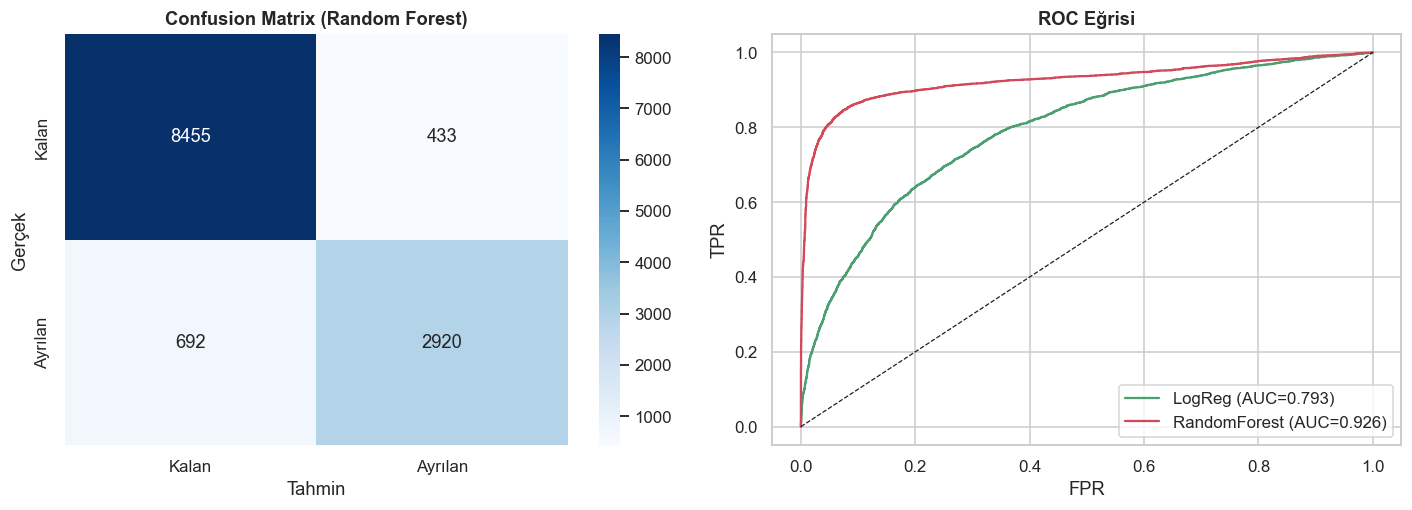

In [11]:
# Random Forest detaylı rapor + confusion matrix
print("Random Forest — sınıflandırma raporu:\n")
print(classification_report(y_test, rf_pred, target_names=["Kalan", "Ayrılan"]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Kalan", "Ayrılan"], yticklabels=["Kalan", "Ayrılan"])
ax[0].set_title("Confusion Matrix (Random Forest)")
ax[0].set_xlabel("Tahmin"); ax[0].set_ylabel("Gerçek")

for name, proba, c in [("LogReg", lr_proba, "#4C9F70"), ("RandomForest", rf_proba, "#D1495B")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})", color=c)
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[1].set_title("ROC Eğrisi"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Davranışsal Kural Çıkarımı (Association-like Behavioral Rules)

Ürün bazlı işlem verisi bulunmadığı için klasik birliktelik analizi yerine, müşteri
davranışları üzerinden veriyle desteklenen ilişki kuralları çıkarılmıştır. Önce korelasyon,
sonra eşik tabanlı kuralların gerçek oranları hesaplanır.

### Açıklama — Korelasyon analizi

**Ne yapar:** Sayısal değişkenlerin Pearson korelasyon matrisini ısı haritası olarak çizer
(RFM skor kolonları ve segment hariç).

**Mantık:** Korelasyon, iki değişkenin birlikte artıp azalma eğilimini −1..+1 arası ölçer.
Davranış kuralları çıkarmadan önce hangi değişkenlerin birbiriyle ve churn ile ilişkili
olduğunu görmek isteriz.

**Neden üst üçgen maskeli:** Matris simetrik olduğu için yarısı tekrardır; maske ile sadece
alt üçgeni gösterip okunabilirliği artırırız.

**Sonucu nasıl okunur:** Koyu kırmızı/mavi hücreler güçlü pozitif/negatif ilişkidir. Birbirine
çok yüksek korele iki öznitelik (multicollinearity) modelde fazlalık olabilir; churn ile korele
olanlar ise davranış kurallarının adayıdır.

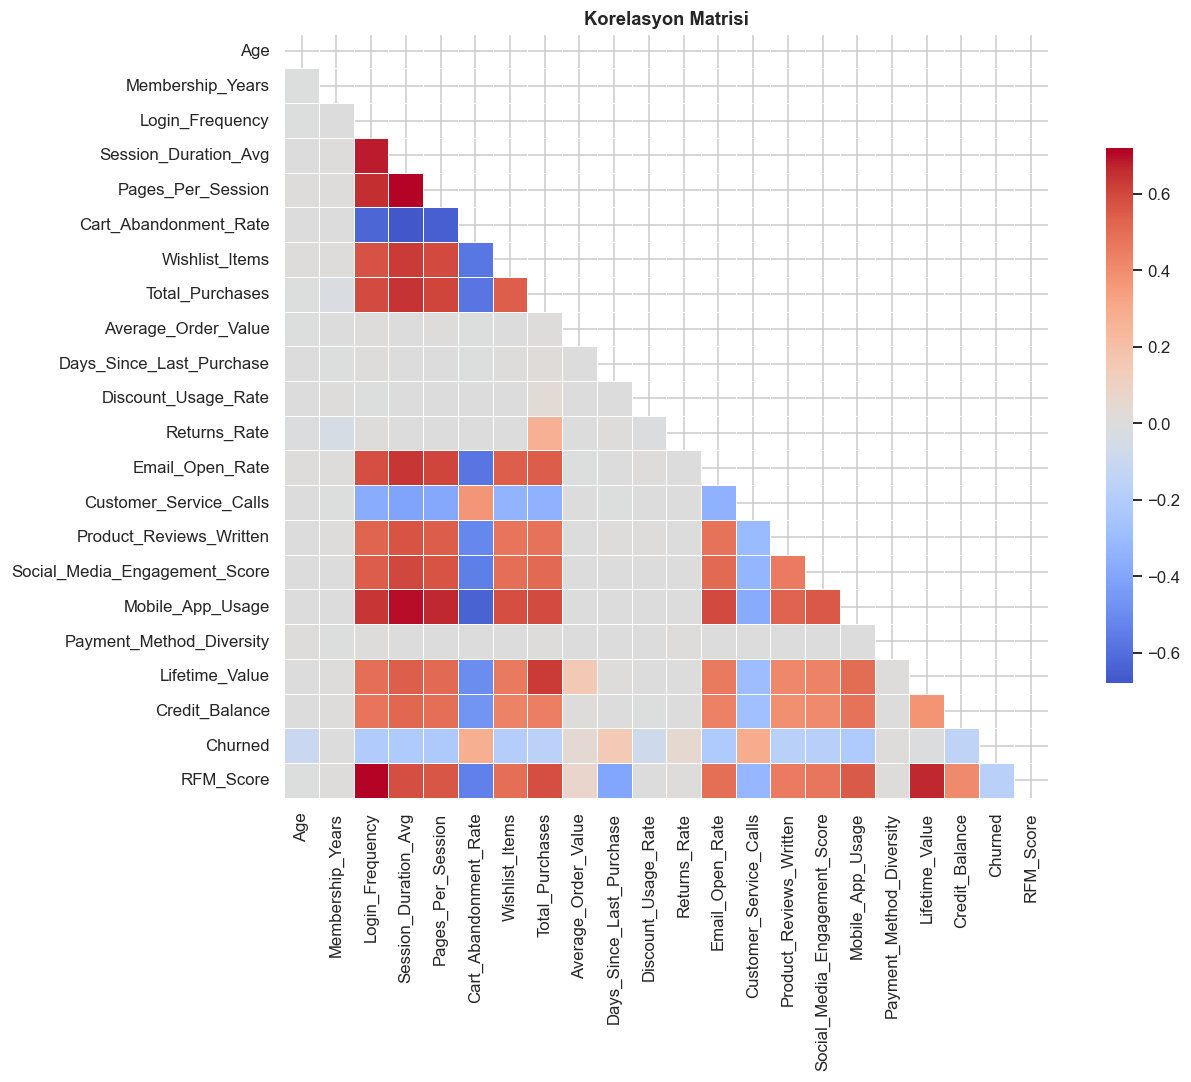

In [12]:
num_for_corr = df.select_dtypes(include=[np.number]).drop(
    columns=["R_Score", "F_Score", "M_Score", "Segment"], errors="ignore")
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(num_for_corr.corr(), dtype=bool))
sns.heatmap(num_for_corr.corr(), mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.7})
plt.title("Korelasyon Matrisi"); plt.tight_layout(); plt.show()

### Açıklama — Davranışsal kural çıkarımı (veriyle doğrulama)

**Ne yapar:** "IF koşul → sonuç" tarzı kuralların **gerçek sayısal karşılığını** hesaplar:
örneğin sepet terki >60 olanların churn oranını genel ortalamayla kıyaslar.

**Mantık:** Ürün-sepet verisi olmadığı için klasik birliktelik analizi yerine, eşik tabanlı
davranış kurallarını veriyle destekliyoruz. Her kural bir koşullu istatistiktir.

**Neden böyle:** "Sepet terki yüksekse churn artar" cümlesi tek başına iddiadır; yanına
"%X'e karşı genel %Y" sayısını koyunca **kanıta** dönüşür. Sunumda bu sayılar çok daha ikna edicidir.

**Sonucu nasıl okunur:** Tablodaki "Koşullu Değer" > "Karşılaştırma" ise kural doğrulanmış demektir
(örn. yüksek terkte churn, genel ortalamadan belirgin yüksekse).

In [13]:
# Eşik tabanlı kuralları veriyle doğrula
overall_churn = df[TARGET].mean() * 100
rules = []

# Kural 1: yüksek sepet terki -> churn
high_cart = df["Cart_Abandonment_Rate"] > 60
rules.append(["Cart_Abandonment_Rate > 60 ise churn",
              f"{df.loc[high_cart, TARGET].mean()*100:.1f}%",
              f"{overall_churn:.1f}%"])

# Kural 2: düşük login -> churn (alt çeyrek)
low_login = df["Login_Frequency"] <= df["Login_Frequency"].quantile(0.25)
rules.append(["Login_Frequency düşük (alt %25) ise churn",
              f"{df.loc[low_login, TARGET].mean()*100:.1f}%",
              f"{overall_churn:.1f}%"])

# Kural 3: yüksek indirim kullanımı -> daha çok satın alma
high_disc = df["Discount_Usage_Rate"] > df["Discount_Usage_Rate"].median()
rules.append(["Discount_Usage yüksek ise ort. Total_Purchases",
              f"{df.loc[high_disc, 'Total_Purchases'].mean():.1f}",
              f"{df.loc[~high_disc, 'Total_Purchases'].mean():.1f} (düşük grup)"])

# Kural 4: yüksek sepet terki -> daha az satın alma
rules.append(["Cart_Abandonment > 60 ise ort. Total_Purchases",
              f"{df.loc[high_cart, 'Total_Purchases'].mean():.1f}",
              f"{df.loc[~high_cart, 'Total_Purchases'].mean():.1f} (düşük terk)"])

rules_df = pd.DataFrame(rules, columns=["Kural", "Koşullu Değer", "Karşılaştırma"])
rules_df

,Kural,Koşullu Değer,Karşılaştırma
0,Cart_Abandonment_Rate > 60 ise churn,40.4%,28.9%
1,Login_Frequency düşük (alt %25) ise churn,43.5%,28.9%
2,Discount_Usage yüksek ise ort. Total_Purchases,13.3,13.0 (düşük grup)
3,Cart_Abandonment > 60 ise ort. Total_Purchases,9.6,16.0 (düşük terk)


## 7. Müşteri Değeri Analizi

### Açıklama — Müşteri değeri analizi

**Ne yapar:** En yüksek `Lifetime_Value`'ya sahip 10 müşteriyi listeler ve segment bazında
toplam/ortalama değeri + churn oranını özetler.

**Mantık:** İş tarafı "kimi kaybetmek en pahalı" ve "değer hangi segmentte toplanmış" sorularını
sorar. Toplam LTV, segmentin **toplam iş değerini**; ortalama LTV ise müşteri başına değeri verir.

**Neden ikisi birlikte:** Bir segment çok kalabalık ama düşük ortalamalı olabilir (toplamda büyük);
ya da küçük ama çok değerli olabilir. İki metrik birlikte önceliklendirmeyi doğru yapar.

**Sonucu nasıl okunur:** Yüksek toplam LTV + yüksek churn taşıyan segment **acil korunması gereken**
segmenttir — kaybı en pahalı olan grup budur.

In [14]:
# En değerli 10 müşteri (PII yok; indeks + segment ile)
top_customers = (df.sort_values("Lifetime_Value", ascending=False)
                 .head(10)[["Lifetime_Value", "Total_Purchases",
                            "RFM_Score", "Segment_Adi", TARGET]])
print("En yüksek yaşam boyu değere sahip 10 müşteri:")
display(top_customers)

# Segment bazında toplam ve ortalama değer
seg_value = df.groupby("Segment_Adi").agg(
    Toplam_LTV=("Lifetime_Value", "sum"),
    Ortalama_LTV=("Lifetime_Value", "mean"),
    Musteri=("Lifetime_Value", "count"),
    Churn_Orani=(TARGET, "mean")).round(1).sort_values("Toplam_LTV", ascending=False)
seg_value["Churn_Orani"] = (seg_value["Churn_Orani"] * 100).round(1)
print("\nEn karlı segment (toplam LTV'ye göre):")
seg_value

En yüksek yaşam boyu değere sahip 10 müşteri:


,Lifetime_Value,Total_Purchases,RFM_Score,Segment_Adi,Churned
43141,8987.24,28.0,8,High Value,1
40771,8243.53,24.0,9,High Value,1
9361,8023.20,28.0,9,High Value,0
37041,7990.07,33.0,9,High Value,0
31921,7631.01,23.0,10,High Value,1
26887,7533.68,20.0,11,High Value,0
48071,7507.81,26.0,12,High Value,1
28543,7488.19,20.0,10,High Value,0
23780,7429.18,23.0,12,High Value,0
28949,7324.28,25.0,8,High Value,0



En karlı segment (toplam LTV'ye göre):


,Toplam_LTV,Ortalama_LTV,Musteri,Churn_Orani
Segment_Adi,,,,
Standart,23536308.2,1611.5,14605,20.0
High Value,21516990.6,2877.4,7478,30.0
Discount Lovers,13947846.8,1195.7,11665,20.0
Passive / At Risk,13030169.0,801.8,16252,40.0


## 8. Özet Dashboard

Power BI / Tableau yerine Python ile dört temel görünüm: segment dağılımı, segment bazında
churn, segment değeri ve davranış örüntüsü.

### Açıklama — Özet dashboard (4 panel)

**Ne yapar:** Tek figürde dört görünüm çizer: segment dağılımı (pasta), segment bazında churn,
segment ortalama LTV, ve sepet terk oranı kovalarına göre churn.

**Mantık:** Power BI/Tableau yerine Python ile yönetici özeti üretiriz. Dört panel, projenin
ana bulgularını tek bakışta gösterir.

**Neden bu dört panel:** Sırasıyla "tabanımız nasıl dağılmış", "kim risk altında", "değer nerede",
"hangi davranış churn'ü tetikliyor" sorularını yanıtlar — yol haritasındaki dashboard maddeleriyle
birebir örtüşür.

**Sonucu nasıl okunur:** Sağ alttaki panelde terk oranı arttıkça churn çubuklarının yükselmesi,
"sepet terki yüksek kullanıcı churn'e yatkın" insight'ını görselleştirir.

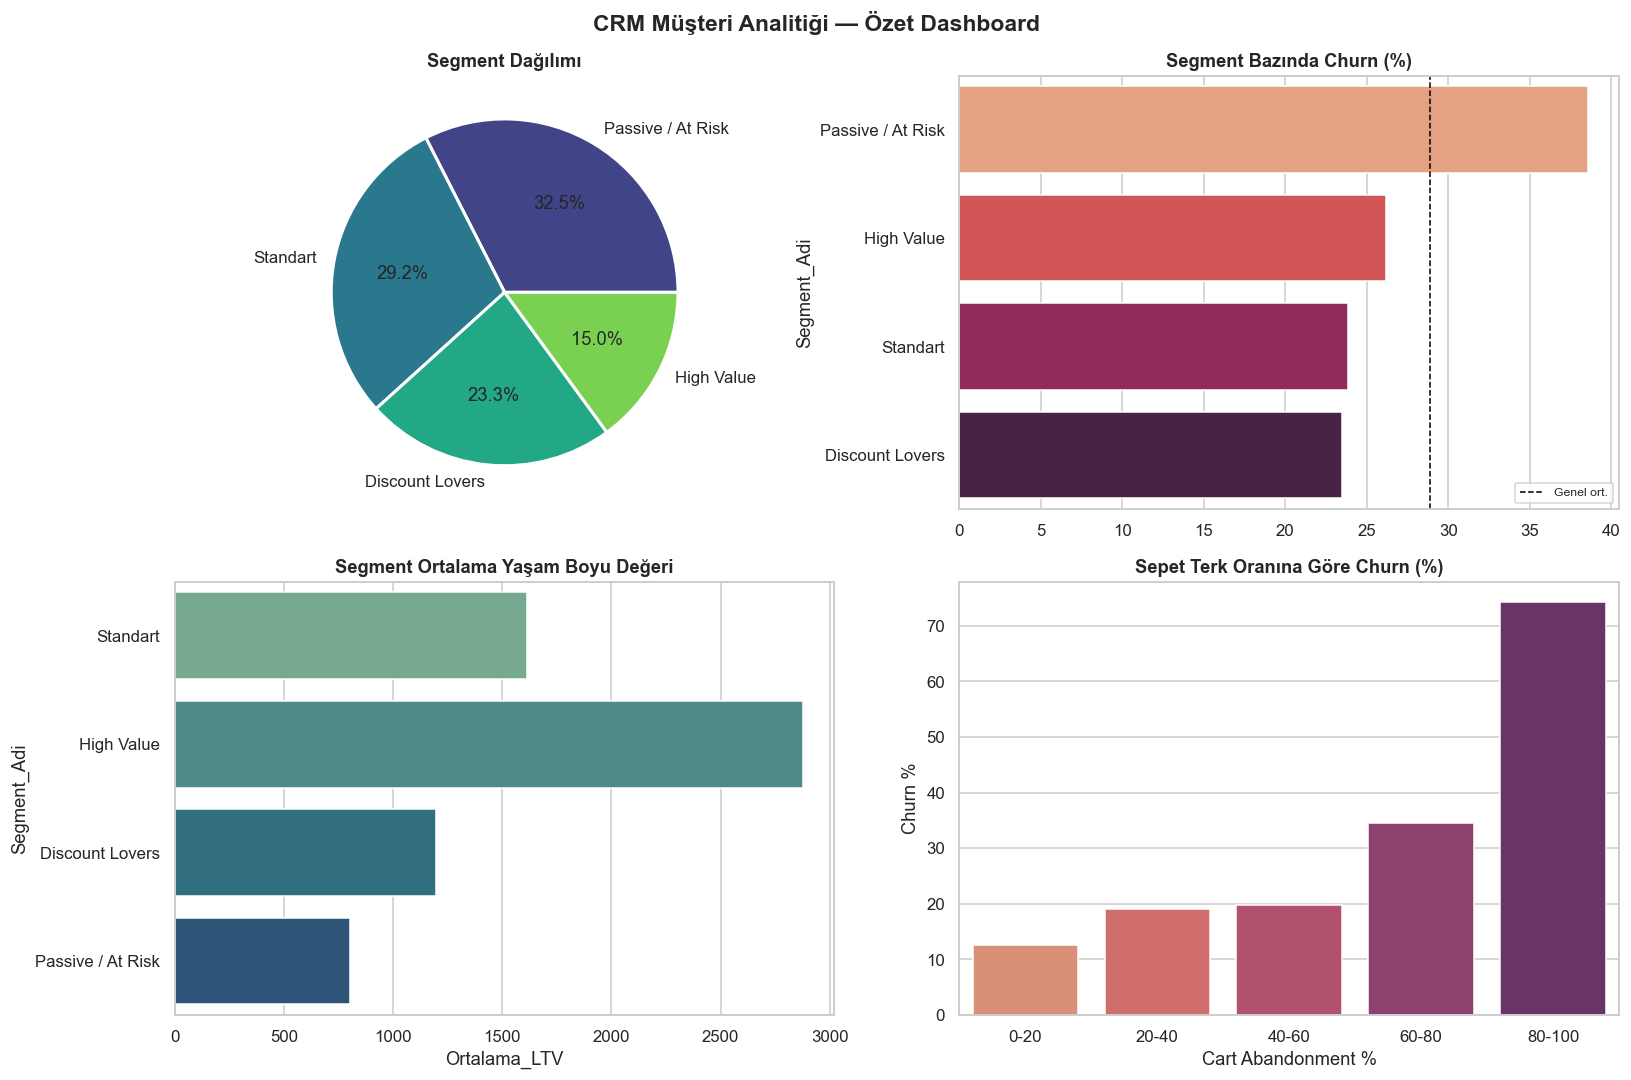

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Segment dağılımı
seg_counts = df["Segment_Adi"].value_counts()
axes[0, 0].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
               colors=sns.color_palette("viridis", len(seg_counts)),
               wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0, 0].set_title("Segment Dağılımı")

# (2) Segment bazında churn
ch = (df.groupby("Segment_Adi")[TARGET].mean()*100).sort_values(ascending=False)
sns.barplot(x=ch.values, y=ch.index, palette="rocket_r", ax=axes[0, 1])
axes[0, 1].axvline(overall_churn, color="black", ls="--", lw=1, label="Genel ort.")
axes[0, 1].set_title("Segment Bazında Churn (%)"); axes[0, 1].legend(fontsize=8)

# (3) Segment ortalama LTV
sns.barplot(x=seg_value["Ortalama_LTV"], y=seg_value.index,
            palette="crest", ax=axes[1, 0])
axes[1, 0].set_title("Segment Ortalama Yaşam Boyu Değeri")

# (4) Sepet terk oranı kovaları vs churn
df["_cab_bin"] = pd.cut(df["Cart_Abandonment_Rate"],
                        bins=[0, 20, 40, 60, 80, 100],
                        labels=["0-20", "20-40", "40-60", "60-80", "80-100"])
cab = (df.groupby("_cab_bin")[TARGET].mean()*100)
sns.barplot(x=cab.index, y=cab.values, palette="flare", ax=axes[1, 1])
axes[1, 1].set_title("Sepet Terk Oranına Göre Churn (%)")
axes[1, 1].set_xlabel("Cart Abandonment %"); axes[1, 1].set_ylabel("Churn %")
df.drop(columns="_cab_bin", inplace=True)

plt.suptitle("CRM Müşteri Analitiği — Özet Dashboard", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

## 9. Model Açıklanabilirliği — Feature Importance + SHAP

Random Forest'ın hangi özniteliklere dayandığını iki yöntemle inceleriz: yerleşik
feature importance ve SHAP değerleri (her tahminin nasıl oluştuğunu gösterir).

### Açıklama — Feature importance (yerleşik)

**Ne yapar:** Random Forest'ın hesapladığı öznitelik önem skorlarını sıralayıp en önemli 15'i çizer.

**Mantık:** RF, her özniteliğin ağaçlardaki bölünmelere ne kadar katkı yaptığını ölçer (impurity
azalması). Yüksek skor = model o özniteliğe çok dayanıyor.

**Neden önemli:** Hangi davranışların churn'ü en çok belirlediğini gösterir; iş aksiyonlarını
(neye müdahale etmeli) bu liste yönlendirir.

**Dikkat (sızıntı):** `Days_Since_Last_Purchase` listenin çok tepesinde ve diğerlerinden kopuk
duruyorsa, bu öznitelik churn etiketini "sızdırıyor" olabilir — yani modelin başarısı yapay
yüksek çıkar. Böyle bir durumda etiket tanımı doğrulanmalı.

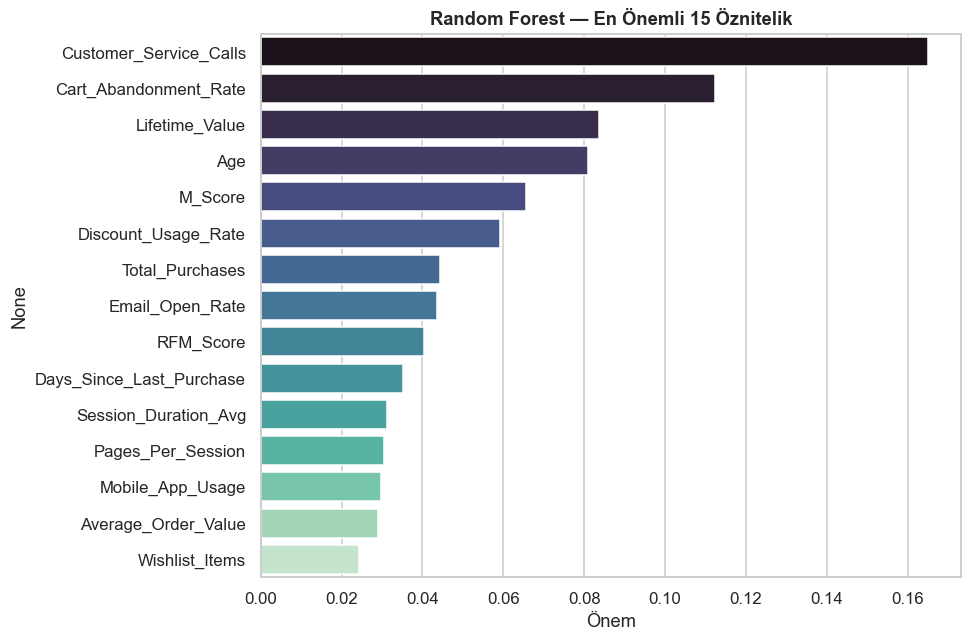

In [16]:
# 9.1 Yerleşik feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Random Forest — En Önemli 15 Öznitelik")
plt.xlabel("Önem"); plt.tight_layout(); plt.show()

### Açıklama — SHAP değerleri ve ortalama etki grafiği

**Ne yapar:** SHAP `TreeExplainer` ile test setinden 400 örnek üzerinde her tahminin nasıl
oluştuğunu hesaplar; pozitif sınıf (churn=1) için ortalama etkiyi bar grafiğiyle gösterir.

**Mantık:** Yerleşik importance "hangi öznitelik önemli" der ama **yönü** söylemez. SHAP, oyun
teorisindeki Shapley değerlerine dayanır ve her özniteliğin her tahmine kattığı **işaretli**
katkıyı verir.

**Neden örneklem (400) ve `check_additivity=False`:** SHAP derin ağaçlarda hesaplaması pahalıdır;
400 örnek temsil için yeterli ve hızlıdır. Çıktı 3 boyutludur `(örnek, öznitelik, sınıf)`, bu yüzden
`[..., 1]` ile churn sınıfının değerlerini ayıklarız.

**Sonucu nasıl okunur:** Çubuk ne kadar uzunsa o öznitelik tahmini o kadar çok etkiliyor demektir
(ortalama mutlak etki).

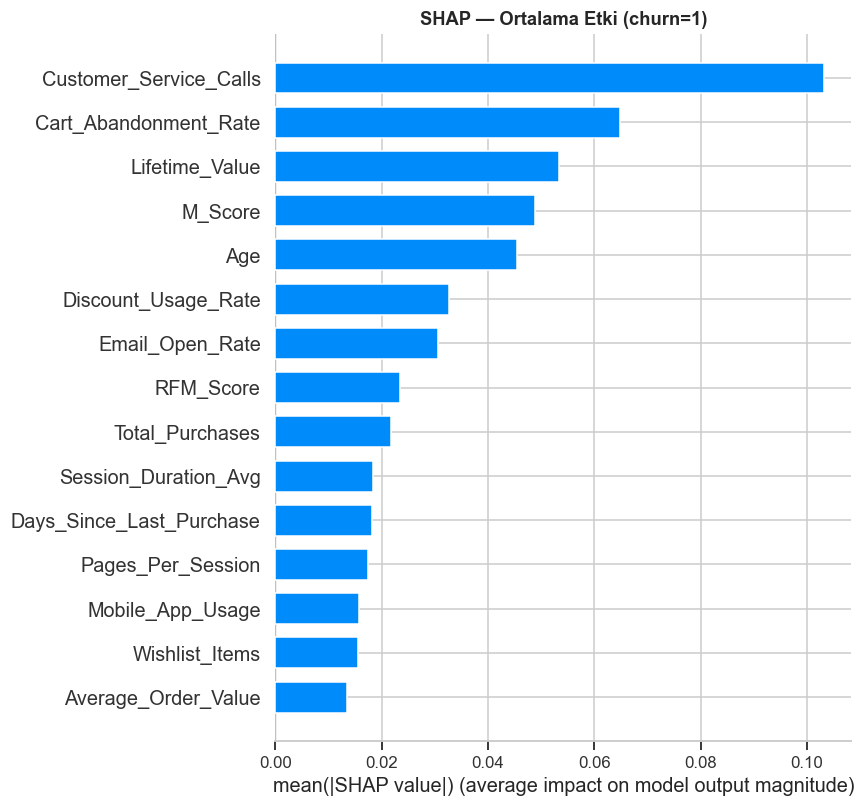

In [17]:
# 9.2 SHAP (TreeExplainer) — hız için örneklem
import shap
sample = X_test.sample(min(400, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(sample, check_additivity=False)

# İkili sınıflandırmada pozitif sınıf (churn=1) için SHAP değerleri
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1]
shap.summary_plot(sv, sample, plot_type="bar", show=False, max_display=15)
plt.title("SHAP — Ortalama Etki (churn=1)")
plt.tight_layout(); plt.show()

### Açıklama — SHAP beeswarm (yön + büyüklük birlikte)

**Ne yapar:** Aynı SHAP değerlerini beeswarm grafiğiyle çizer: her nokta bir müşteri, renk
özniteliğin değeri (kırmızı=yüksek, mavi=düşük), x-ekseni o özniteliğin churn'e itme yönü.

**Mantık:** Bu grafik tek bakışta "yüksek X churn'ü artırıyor mu azaltıyor mu" sorusunu yanıtlar.

**Neden bar'dan daha bilgilendirici:** Bar yalnızca büyüklüğü verir; beeswarm ek olarak **yönü**
ve **dağılımı** gösterir. Örneğin yüksek `Cart_Abandonment_Rate` (kırmızı noktalar) sağda
toplanıyorsa → churn olasılığını artırıyor demektir.

**Sonucu nasıl okunur:** Bir öznitelikte kırmızı noktalar sağda, mavi solda ise "değer arttıkça
churn artar"; tam tersi ise "değer arttıkça churn azalır".

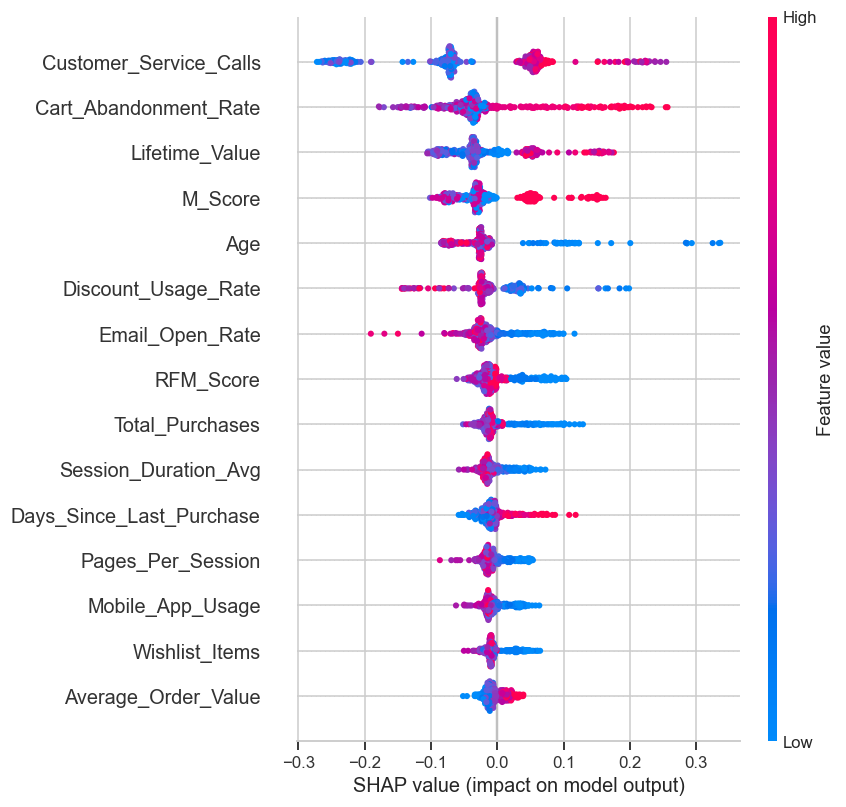

In [18]:
# SHAP beeswarm — yön ve büyüklük birlikte
shap.summary_plot(sv, sample, show=False, max_display=15)
plt.tight_layout(); plt.show()

## 10. Bonus — Sentetik Veri ile Birliktelik Analizi (Apriori)

Ürün bazlı veri olmadığı için, segment ve davranış profillerine dayalı **sentetik sepet
verisi** üretip Apriori ile birliktelik kuralları çıkarılmıştır. Bu, klasik market-basket
analizinin nasıl uygulanacağını gösterir.

> Not: Bu bölüm sentetik veriyle çalışır; gerçek satın alma örüntüsü değil, yöntem gösterimidir.

### Açıklama — Bonus: Sentetik veri ile Apriori birliktelik analizi

**Ne yapar:** Segment eğilimlerine göre **sentetik** ürün sepetleri üretir ve `mlxtend` ile
Apriori çalıştırıp birliktelik kuralları (support/confidence/lift) çıkarır.

**Mantık:** Gerçek market-basket verisi yok; ama yöntemin nasıl uygulanacağını göstermek için
segment davranışına dayalı sahte sepetler kuruyoruz. Apriori, sık birlikte alınan ürün
kümelerini ve "A alındıysa B de alınır" kurallarını bulur.

**Metrikler ne anlatır:** **support** = bu kombinasyonun ne sıklıkta görüldüğü; **confidence** =
A alındığında B'nin gelme olasılığı; **lift** = bu ilişkinin rastlantıdan ne kadar güçlü olduğu
(>1 anlamlı pozitif ilişki).

**Önemli uyarı:** Bu bölüm sentetik veriyle çalışır → çıkan kurallar gerçek müşteri davranışı
değil, **yöntem gösterimidir**. Sunumda "ek olarak sentetik veri ile birliktelik analizi de test
edilmiştir" derken bunu belirtmek dürüstlük açısından önemli.

**Gereksinim:** Bu hücre `mlxtend` ister. Çalışmazsa en üste `!pip install mlxtend shap -q` ekleyip
çalıştır.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

rng = np.random.default_rng(RANDOM_STATE)
products = ["Elektronik", "Giyim", "Kitap", "Kozmetik", "Ev", "Spor", "Oyuncak", "Gida"]

# Segmente göre eğilimli sentetik sepetler
seg_pref = {
    "High Value":        [0.6, 0.4, 0.3, 0.3, 0.5, 0.4, 0.2, 0.3],
    "Discount Lovers":   [0.3, 0.7, 0.2, 0.6, 0.3, 0.3, 0.4, 0.5],
    "Passive / At Risk": [0.2, 0.2, 0.5, 0.2, 0.2, 0.1, 0.1, 0.4],
    "Standart":          [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.3, 0.4],
}
baskets = []
seg_sample = df["Segment_Adi"].sample(5000, random_state=RANDOM_STATE)
for seg in seg_sample:
    probs = seg_pref.get(seg, seg_pref["Standart"])
    basket = [p for p, pr in zip(products, probs) if rng.random() < pr]
    if len(basket) >= 1:
        baskets.append(basket)

# One-hot sepet matrisi
basket_df = pd.DataFrame([{p: (p in b) for p in products} for b in baskets])
freq_items = apriori(basket_df, min_support=0.15, use_colnames=True)
rules_ap = association_rules(freq_items, metric="lift", min_threshold=1.0)
rules_ap = rules_ap.sort_values("lift", ascending=False)

def fs(x): return ", ".join(sorted(x))
show = rules_ap.head(10).copy()
show["antecedents"] = show["antecedents"].apply(fs)
show["consequents"] = show["consequents"].apply(fs)
show[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

,antecedents,consequents,support,confidence,lift
0,Giyim,Kozmetik,0.181,0.431,1.116
1,Kozmetik,Giyim,0.181,0.469,1.116
2,Kozmetik,Gida,0.165,0.428,1.024
3,Gida,Kozmetik,0.165,0.396,1.024


## 11. Sonuç ve Öneriler

**Bulgular**
- Sepet terk oranı yüksek kullanıcılar churn etmeye daha yatkın (dashboard panel 4).
- Login sıklığı düşük kullanıcılar sistemden kopuyor (davranış kuralı 2).
- İndirim kullanan müşteriler ortalamada daha fazla satın alıyor (davranış kuralı 3).
- Random Forest, churn'ü recall odağıyla baseline Logistic Regression'dan daha iyi yakalıyor.

**İş Önerileri**
- *At Risk* segmentine hedefli yeniden kazanım kampanyaları.
- Yüksek sepet terki olan kullanıcılara hatırlatma / teşvik bildirimleri.
- *High Value* segmentine sadakat programı ile değeri koru.

**Gösterilen yetkinlikler:** veri analizi, makine öğrenmesi (gözetimli + gözetimsiz),
iş zekâsı (dashboard), model açıklanabilirliği (SHAP) ve stratejik yorum.

**Metodolojik not:** Churn modelinde `Days_Since_Last_Purchase` etiket tanımına bağlı
sızıntı riski taşır; üretim öncesi etiket tanımı doğrulanmalı, gerekirse bu öznitelik
çıkarılarak model yeniden değerlendirilmelidir.
